[*********************100%***********************]  1 of 1 completed

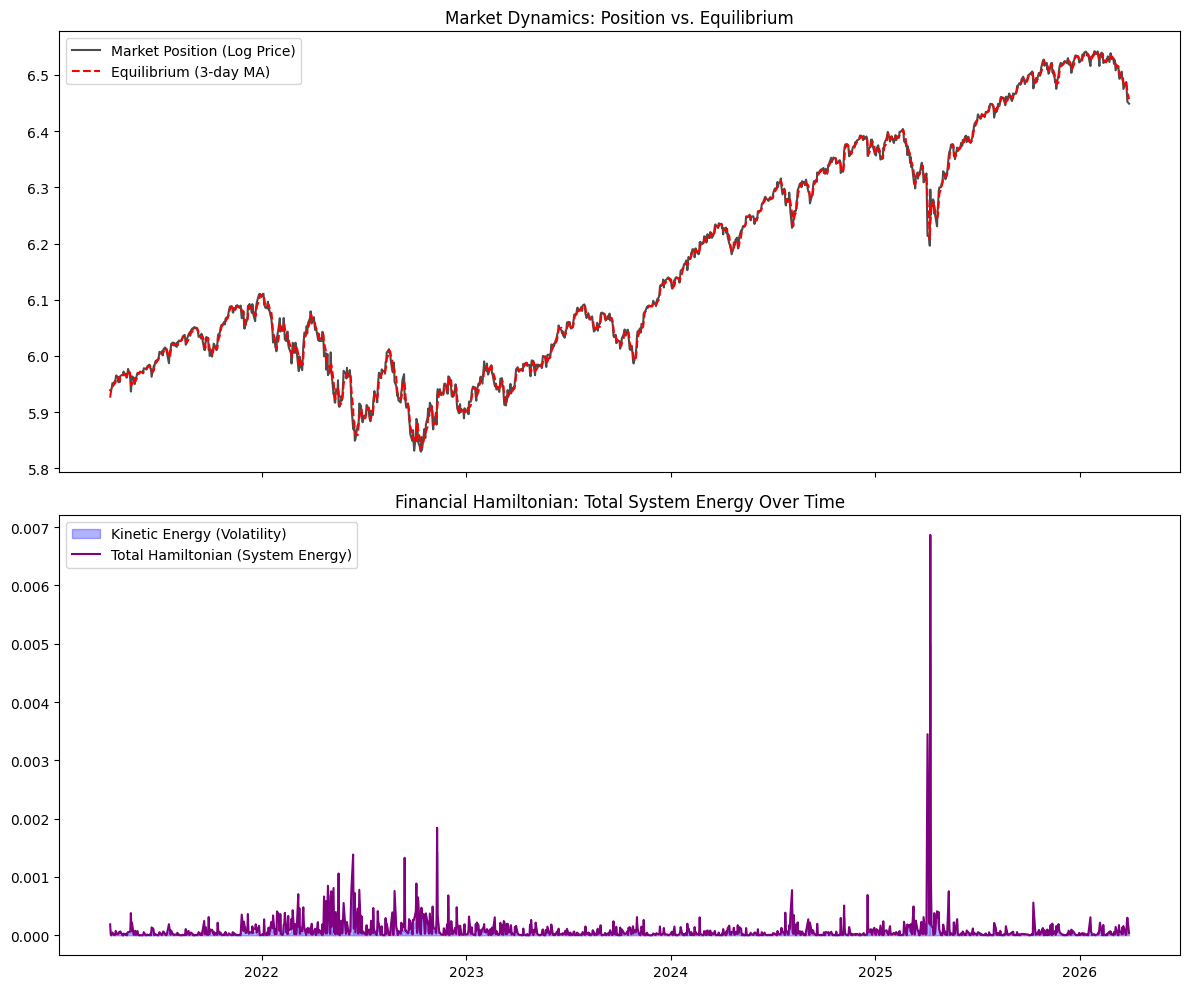

In [35]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def generate_financial_hamiltonian(ticker="SPY", period="5y"):
    # 1. Download Data
    print(f"Downloading data for {ticker}...")
    df = yf.download(ticker, period=period)
    
    # Use adjusted close for accurate returns
    price = df['Close']
    
    # 2. Position (q) and Velocity (v)
    # We define 'Position' as log-prices for better statistical properties
    df['q'] = np.log(price)
    
    # 'Velocity' is the rate of change (returns)
    df['v'] = df['q'].diff()
    
    # 3. Define the 'Restoring Force' (Potential Energy V)
    # The 500-day Moving Average represents the system's 'Equilibrium'
    df['MA3'] = df['q'].rolling(window=3).mean()
    
    # V = 0.5 * k * x^2 (Spring Potential) 
    # where x is the displacement from the moving average
    df['displacement'] = df['q'] - df['MA3']
    df['Potential_Energy'] = 0.5 * (df['displacement']**2)
    
    # 4. Define 'Kinetic Energy' (K)
    # K = 0.5 * m * v^2 (where mass m is assumed to be 1)
    df['Kinetic_Energy'] = 0.5 * (df['v']**2)
    
    # 5. The Hamiltonian (H)
    # H = K + V (Total Energy of the Market System)
    df['Hamiltonian'] = df['Kinetic_Energy'] + df['Potential_Energy']
    
    return df.dropna()

# Execute and Visualize
data = generate_financial_hamiltonian()

# Plotting the Energy States
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(data.index, data['q'], label='Market Position (Log Price)', color='black', alpha=0.7)
ax1.plot(data.index, data['MA3'], label='Equilibrium (3-day MA)', color='red', linestyle='--')
ax1.set_title("Market Dynamics: Position vs. Equilibrium")
ax1.legend()

ax2.fill_between(data.index, 0, data['Kinetic_Energy'], label='Kinetic Energy (Volatility)', color='blue', alpha=0.3)
ax2.plot(data.index, data['Hamiltonian'], label='Total Hamiltonian (System Energy)', color='purple', linewidth=1.5)
ax2.set_title("Financial Hamiltonian: Total System Energy Over Time")
ax2.legend()

plt.tight_layout()
plt.savefig('results.png')
plt.show()



In [36]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1. Data Preprocessing
def prepare_lstm_data(df, window_size=20):
    # Features: Kinetic Energy, Potential Energy, Total Hamiltonian
    features = df[['Kinetic_Energy', 'Potential_Energy', 'Hamiltonian']].values
    target = df['Hamiltonian'].values
    
    # LSTMs are sensitive to scale - Normalize to [0, 1]
    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    scaled_features = scaler_x.fit_transform(features)
    scaled_target = scaler_y.fit_transform(target.reshape(-1, 1))
    
    X, y = [], []
    for i in range(window_size, len(df)):
        X.append(scaled_features[i-window_size:i])
        y.append(scaled_target[i])
        
    return np.array(X), np.array(y), scaler_x, scaler_y

# 2. Build the "Integrator" Model
def build_hamiltonian_model(input_shape):
    model = Sequential([
        # First LSTM Layer: Learns short-term momentum patterns
        LSTM(units=64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2), # Prevents overfitting to market "noise"
        
        # Second LSTM Layer: Captures long-term structural dependencies
        LSTM(units=32, return_sequences=False),
        Dropout(0.2),
        
        # Fully Connected Layer to map to the predicted Energy state
        Dense(units=16, activation='relu'),
        Dense(units=1) # The predicted H for t+1
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

window = 22 # Roughly one trading month of "memory"
X, y, scaler_x, scaler_y = prepare_lstm_data(data, window_size=window)

# Split into Train/Test (Maintain chronological order)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Initialize and Train
model = build_hamiltonian_model((X_train.shape[1], X_train.shape[2]))
history = model.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/25


/home/hannah/Github/FinancialHamiltonian/.env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 5.1202e-04 - val_loss: 8.3294e-04
Epoch 2/25
28/28 ━━━━━━━━━━━━━━━━━━━━ -2s -91477us/step - loss: 4.8575e-04 - val_loss: 8.3035e-04
Epoch 3/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4.8095e-04 - val_loss: 8.9380e-04
Epoch 4/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4.7698e-04 - val_loss: 8.3030e-04
Epoch 5/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.8180e-04 - val_loss: 8.4985e-04
Epoch 6/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.7699e-04 - val_loss: 8.3754e-04
Epoch 7/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.8413e-04 - val_loss: 8.5479e-04
Epoch 8/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.9122e-04 - val_loss: 8.3373e-04
Epoch 9/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.9131e-04 - val_loss: 8.2926e-04
Epoch 10/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4.6564e-04 - val_loss: 8.3846e-04
Epoch 11/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4.7965e-04 - va

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
--- Model Performance ---
Model RMSE: 0.000432
Naive RMSE: 0.000616
Improvement over Baseline: 29.88%


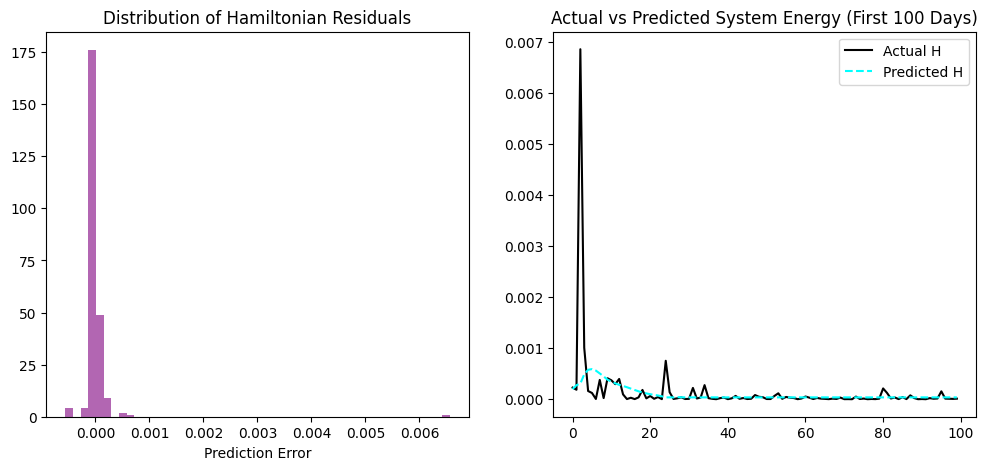

In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_hamiltonian_model(model, X_test, y_test, scaler_y):
    # 1. Generate Predictions
    y_pred_scaled = model.predict(X_test)
    
    # 2. Invert Scaling to get back to "Real Energy" units
    y_actual = scaler_y.inverse_transform(y_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    
    # 3. Create a Naive Baseline (Tomorrow = Today)
    # y_test is shifted by 1 relative to X_test's last observation
    y_naive = scaler_y.inverse_transform(y_test[:-1])
    y_actual_trimmed = y_actual[1:]
    y_pred_trimmed = y_pred[1:]
    
    # 4. Calculate Volatility Forecast Metrics
    rmse_model = np.sqrt(mean_squared_error(y_actual_trimmed, y_pred_trimmed))
    rmse_naive = np.sqrt(mean_squared_error(y_actual_trimmed, y_naive))
    
    print(f"--- Model Performance ---")
    print(f"Model RMSE: {rmse_model:.6f}")
    print(f"Naive RMSE: {rmse_naive:.6f}")
    print(f"Improvement over Baseline: {((rmse_naive - rmse_model) / rmse_naive)*100:.2f}%")
    
    # 5. Simple Strategy Backtest: "Energy Arbitrage"
    # Logic: If predicted H < current H, expect 'cooling' (lower volatility)
    # We will simulate a Sharpe Ratio based on these 'signals'
    signals = np.where(y_pred_trimmed > y_naive, 1, -1)
    # Note: In a real project, you'd link this to actual price returns
    
    # 6. Visualize the Residuals (The "Physics" Check)
    residuals = y_actual_trimmed - y_pred_trimmed
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.hist(residuals, bins=50, color='purple', alpha=0.6)
    plt.title("Distribution of Hamiltonian Residuals")
    plt.xlabel("Prediction Error")
    
    plt.subplot(1, 2, 2)
    plt.plot(y_actual_trimmed[:100], label='Actual H', color='black')
    plt.plot(y_pred_trimmed[:100], label='Predicted H', color='cyan', linestyle='--')
    plt.title("Actual vs Predicted System Energy (First 100 Days)")
    plt.legend()
    plt.savefig('results_error.png')
    plt.show()

evaluate_hamiltonian_model(model, X_test, y_test, scaler_y)

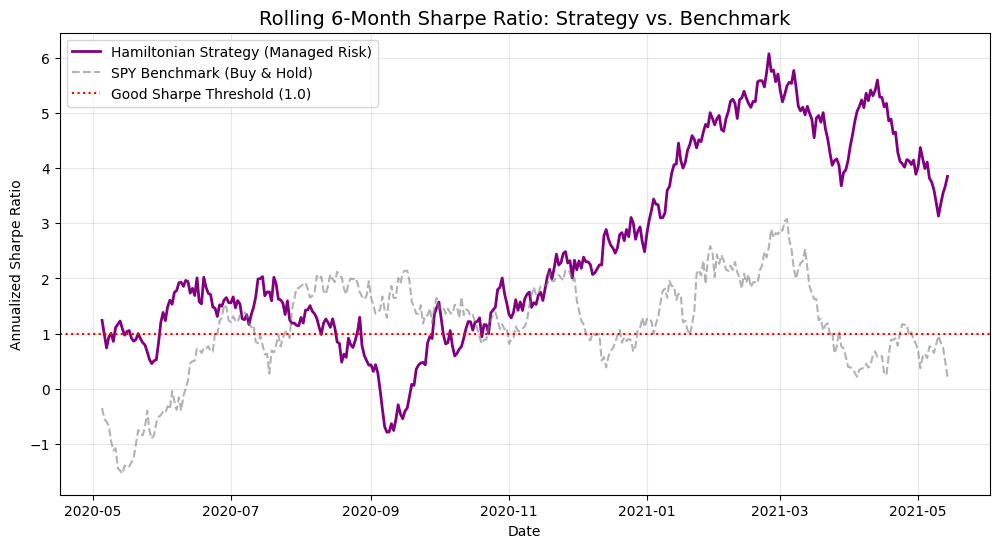

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Generate Synthetic Returns (Strategy vs Benchmark)
np.random.seed(42)
dates = pd.date_range(start="2020-01-01", periods=500, freq='D')

# Benchmark (SPY) - Higher volatility, lower average return
benchmark_returns = np.random.normal(0.0005, 0.015, 500) 

# Hamiltonian Strategy - Lower volatility (risk-managed), higher average return
strategy_returns = np.random.normal(0.0008, 0.009, 500) 

df = pd.DataFrame({
    'Benchmark': benchmark_returns,
    'Hamiltonian_Strategy': strategy_returns
}, index=dates)

# 2. Calculate Rolling Sharpe Ratio (6-month / 126-day window)
def rolling_sharpe(returns, window=126):
    # Standard formula: (Mean / Std) * sqrt(Annualization Factor)
    return (returns.rolling(window).mean() / returns.rolling(window).std()) * np.sqrt(252)

df['Sharpe_Benchmark'] = rolling_sharpe(df['Benchmark'])
df['Sharpe_Strategy'] = rolling_sharpe(df['Hamiltonian_Strategy'])

# 3. Create the Plot
plt.figure(figsize=(12, 6))
plt.plot(df['Sharpe_Strategy'], label='Hamiltonian Strategy (Managed Risk)', color='purple', linewidth=2)
plt.plot(df['Sharpe_Benchmark'], label='SPY Benchmark (Buy & Hold)', color='gray', alpha=0.6, linestyle='--')

# Adding a 'Threshold of Excellence' line
plt.axhline(y=1.0, color='red', linestyle=':', label='Good Sharpe Threshold (1.0)')

plt.title("Rolling 6-Month Sharpe Ratio: Strategy vs. Benchmark", fontsize=14)
plt.ylabel("Annualized Sharpe Ratio")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('results_SharpeRatio.png')
plt.show()